---
numbering: false
---

# 6.2. Inverses

[Chapter 6.1](../01-linear-transformations.ipynb) was a bit of a detour into the world of linear transformations. In theory, one could read Chapter 6.2 here without that knowledge, but the knowledge of linear transformations (in my mind) will help you better appreciate (and understand) the concept of a matrix inverse.

---

## What is an Inverse, Really?

### Scalar Addition and Multiplication

In "regular" addition and multiplication, you're already familiar with the idea of an inverse. In addition, the inverse of a number $a$ is another number $a'$ that satisfies

$$a + a' = a' + a = 0$$

0 is the "identity" element in addition, since adding it to any number $a$ doesn't change the value of $a$. Of course, $a' = -a$, so $-a$ is the **additive inverse** of $a$. Any number $a$ has an additive inverse; for example, the additive inverse of $2$ is $-2$, and the additive inverse of $-2$ is $2$.

In multiplication, the inverse of a number $a$ is another number $a'$ that satisfies

$$a \cdot a' = a' \cdot a = 1$$

1 is the "identity" element in multiplication, since multiplying it by any number $a$ doesn't change the value of $a$. Most numbers have a **multiplicative inverse** of $a' = \frac{1}{a}$, but 0 does not!

$$0 \cdot a' = 0$$

is not achieved by any $a'$.

When a multiplicative inverse exists, we can use it to solve equations like

$$2x = 5$$

by multiplying both sides by the multiplicative inverse of $2$, which is $\frac{1}{2}$.

$$\frac{1}{2} (2x) = \frac{1}{2} (5) \implies x = \frac{5}{2}$$

### Matrices

If $A$ is an $n \times d$ matrix, its additive inverse is just $-A$, which comes from negating each element of $A$. That part is not all that interesting. What we're more interested in is the **multiplicative inverse** of a matrix, which is just referred to as the **inverse** of the matrix.

Suppose $A$ is some $n \times d$ matrix. We'd like to find an inverse, $A'$, such that when $A$ is multiplied by $A'$ **in any order**, the result is the identity element for matrix multiplication, $I$. Recall, the $n \times n$ identity matrix is a matrix with 1s on the diagonal (moving from the top left to the bottom right), and 0s everywhere else. The $3 \times 3$ identity matrix is

$$I_3 = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

$I_3 \vec x = \vec x$ for any $\vec x \in \mathbb{R}^3$, and $B I_3 = I_3 B = B$ for any $B \in \mathbb{R}^{3 \times 3}$.

$$\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} = \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}$$

If $A$ is an $n \times d$ matrix, we'd need a single matrix $A'$ that satisfies

$$AA' = A'A = I$$

In $AA'$, $A'$ is the **right inverse** of $A$, and in $A'A$, $A'$ is the **left inverse** of $A$. Right now, we're interested in finding matrices that have both a left and right inverse, that happen to be the same matrix.

In order to evaluate $AA'$, we'd need $A'$ to be of shape $d \times \text{something}$, and in order to evaluate $A'A$, we'd need $A'$ to be of shape $\text{something else} \times n$. The solution to these constraints is to have $A'$ be a $d \times n$ matrix (like $A^T$).

If we try that, then
- $A'A$ has shape $(d \times n) \cdot (n \times d) = d \times d$
- $AA'$ has shape $(n \times d) \cdot (d \times n) = n \times n$

but, we want $A'A$ and $AA'$ to both be **the same matrix**, not just separate valid matrices. So, we need $n = d$, which requires $A$ to be $n \times n$, like its inverse.

:::{attention} Only square matrices have inverses!
The idea of invertibility only makes sense for square matrices. 

Non-square matrices can have left or right inverses, which we'll discuss in Chapter 6.4, but in general they can't be "invertible".
:::

For example, consider the $2 \times 2$ matrix

$$A = \begin{bmatrix} 2 & 4 \\ 3 & 5\end{bmatrix}$$

It turns out that $A$ does have an inverse! Its inverse, denoted by $A^{-1}$, is

$$A^{-1} = \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix}$$

Because $A^{-1}$ is the matrix that satisfies **both**

$$AA^{-1} = \begin{bmatrix} 2 & 4 \\ 3 & 5\end{bmatrix} \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix} = I$$

and

$$A^{-1}A = \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix} \begin{bmatrix} 2 & 4 \\ 3 & 5\end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix} = I$$

`numpy` is good at finding inverses, when they exist.

In [ ]:
import numpy as np

A = np.array([[2, 4], 
              [3, 5]])
              
np.linalg.inv(A)

array([[-2.5,  2. ],
       [ 1.5, -1. ]])

In [ ]:
# The top-left and bottom-right elements are 1s, 
# and the top-right and bottom-left elements are 0s.
# 4.4408921e-16 is just 0, with some floating point error baked in.
A @ np.linalg.inv(A)

array([[1.0000000e+00, 0.0000000e+00],
       [4.4408921e-16, 1.0000000e+00]])

But, not all square matrices are invertible, just like not all numbers have multiplicative inverses. What happens if we try and invert

$$B = \begin{bmatrix} 1 & 2 \\ 2 & 4\end{bmatrix}$$

In [17]:
B = np.array([[1, 2], 
              [2, 4]])

np.linalg.inv(B)

LinAlgError: Singular matrix

We're told the matrix is **singular**, meaning that it's not invertible.

The point of this section is to understand **why** some square matrices are invertible and others are not, and what the inverse of an invertible matrix really means.

---

## The Goal: Solving Systems of Equations

In general, suppose $A$ is an $n \times d$ matrix and $\vec b \in \mathbb{R}^n$. Then, the equation

$$A \vec x = \vec b$$

is a system of $n$ equations in $d$ unknowns. 

$$\underbrace{\begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1d} \\ a_{21} & a_{22} & \cdots & a_{2d} \\ \vdots & \vdots & \ddots & \vdots \\ a_{n1} & a_{n2} & \cdots & a_{nd} \end{bmatrix}}_{A} \underbrace{\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix}}_{\vec x} = \underbrace{\begin{bmatrix} b_1 \\ b_2 \\ \vdots \\ b_n \end{bmatrix}}_{\vec b}$$

There may be no solution, a unique solution, or infinitely many solutions for the vector $\vec x$ that satisfies the system, depending on $\text{rank}(A)$ and whether $\vec b$ is in $\text{colsp}(A)$.

If we assume $A$ is square, i.e. $n = d$, then $A \vec x = \vec b$ is a system of $n$ equations in $n$ unknowns. If $A$ is invertible (which, remember, only square matrices can be), then there is a unique solution to the system, and we can find it by multiplying both sides by $A^{-1}$ on the left.

$$A \vec x = \vec b \implies A^{-1} A \vec x = A^{-1} \vec b \implies \vec x = A^{-1} \vec b$$

$\vec x = A^{-1} \vec b$ is the unique solution to the system of equations, and we can find it without having to manually solve the system. Thinking back to the example above, we used `numpy` to find that the inverse of


$$A = \begin{bmatrix} 2 & 4 \\ 3 & 5\end{bmatrix}$$

is

$$A^{-1} = \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix}$$

We can use $A^{-1}$ to solve the system

$$\begin{align*} 2x_1 + 4x_2 &= b_1 \\ 3x_1 + 5x_2 &= b_2 \end{align*}$$

For any $b_1, b_2 \in \mathbb{R}$, the unique solution for $x_1$ and $x_2$ is

$$\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} -5/2 & 2 \\ 3/2 & -1\end{bmatrix} \begin{bmatrix} b_1 \\ b_2 \end{bmatrix} = \begin{bmatrix} -5/2 b_1 + 2 b_2 \\ 3/2 b_1 - b_2 \end{bmatrix}$$

That said, as we'll discuss at the bottom of this section, actually finding the inverse of a matrix is very computationally intensive, so usually we don't actually compute $A^{-1}$. Knowing that it exists, and understanding the properties it satisfies, is the important part.

---

## Inverting a Transformation

Remember, the big goal of this section is to find the inverse of a square matrix $A$. 

Since a square matrix $A$ corresponds to a linear transformation, we can think of $A^{-1}$ as "reversing" or "undoing" the transformation.

For example, if $A$ scales vectors, $A^{-1}$ should scale by the reciprocal, so that applying $A$ and then $A^{-1}$ returns the original vector.

The simplest case involves a diagonal matrix, like

$$A = \begin{bmatrix} 2 & 0 \\ 0 & -1/3 \end{bmatrix}$$

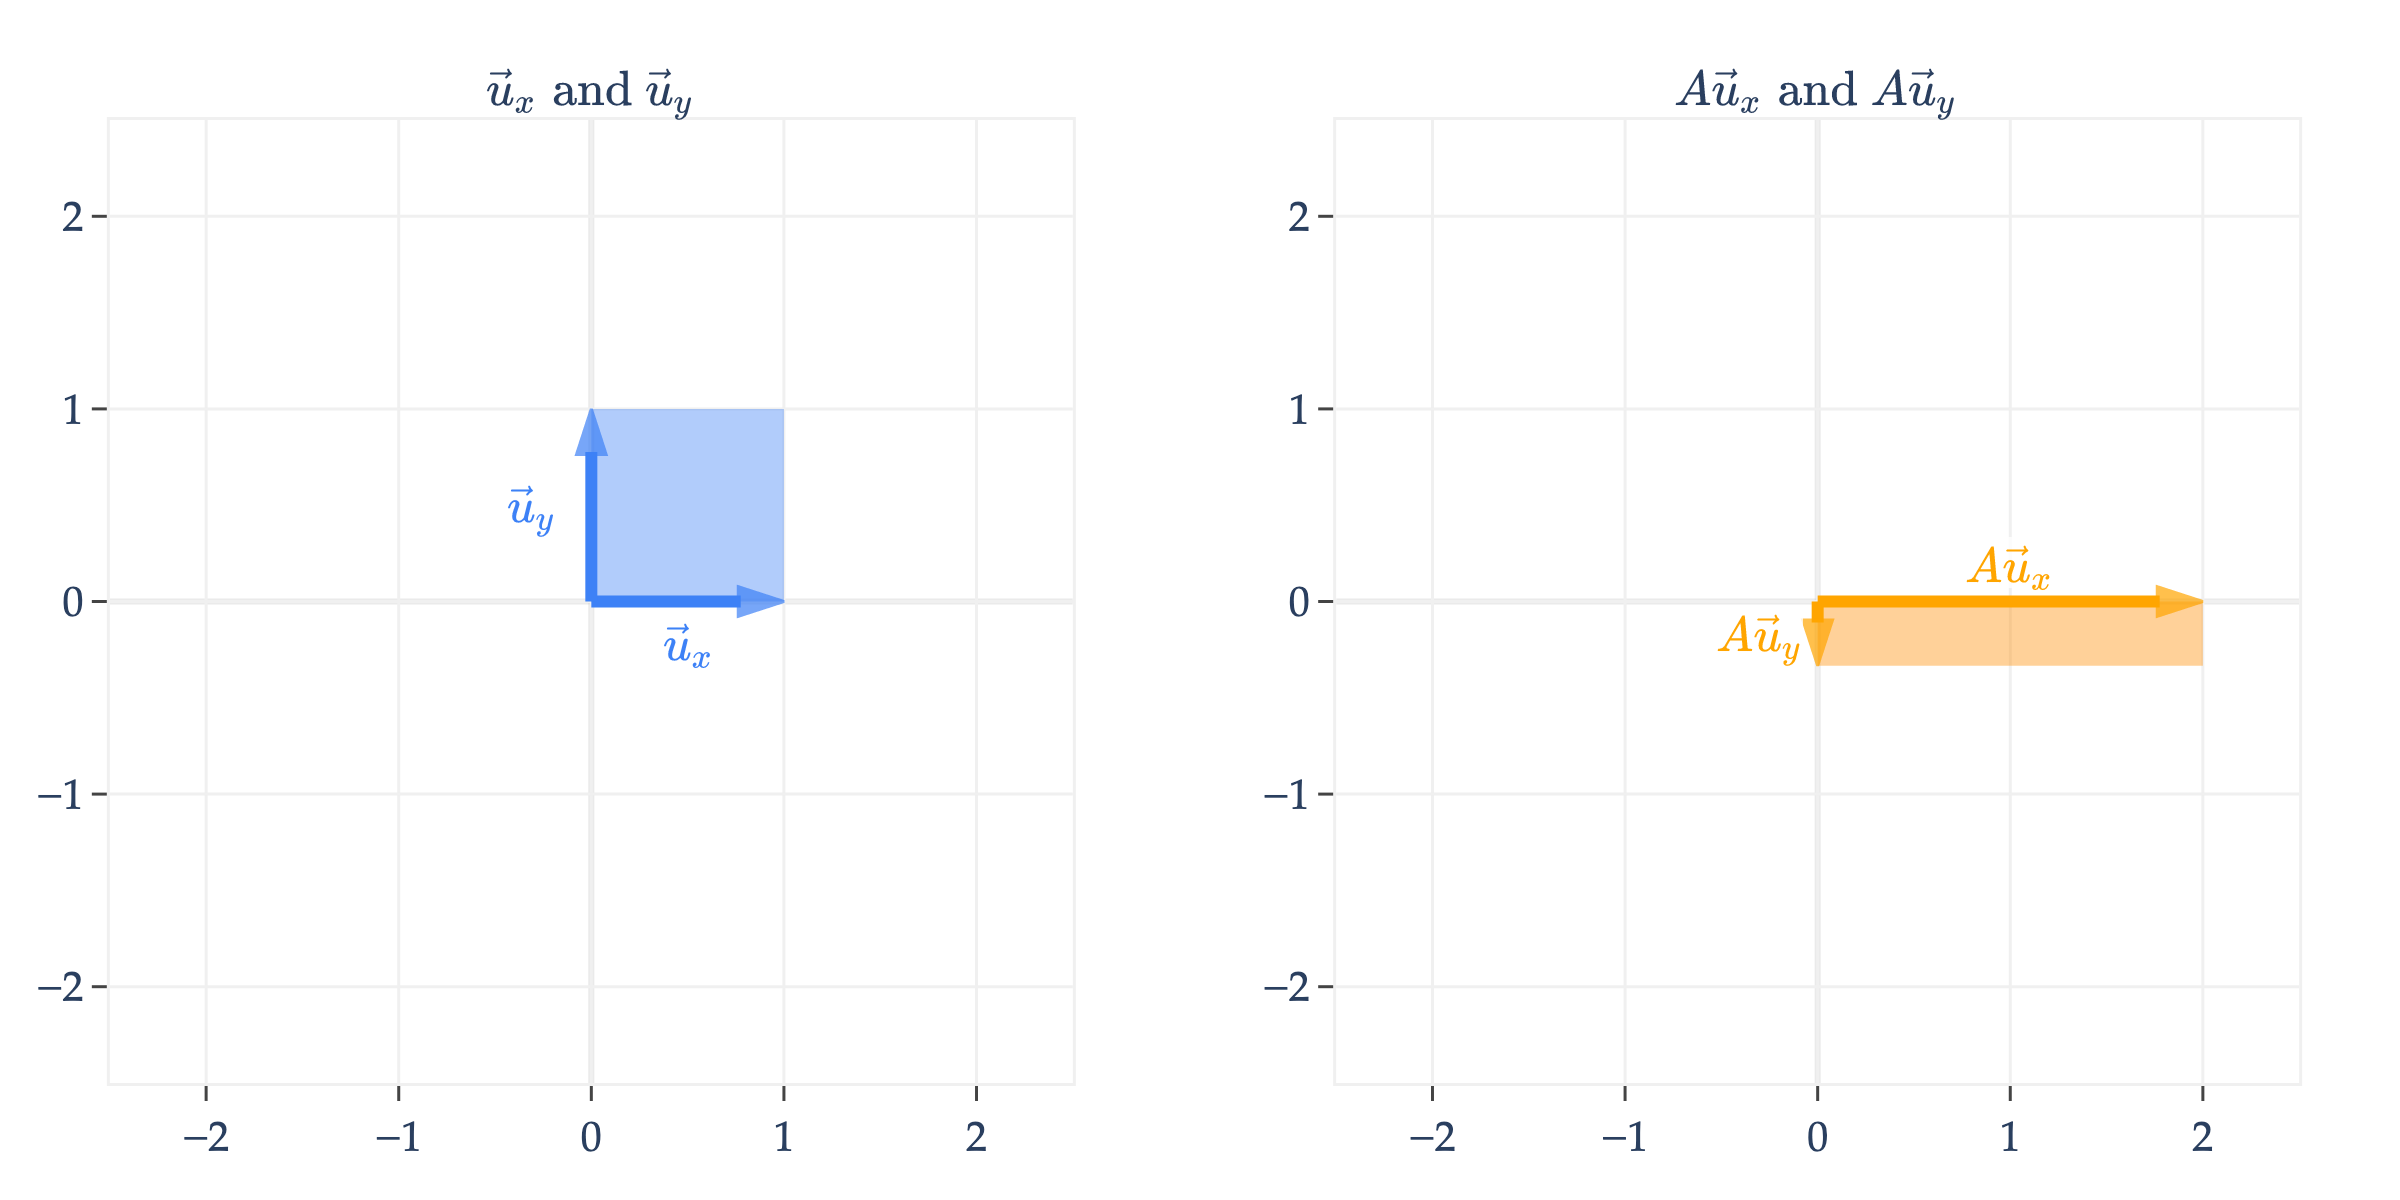

In [237]:
A = np.array([[2, 0], [0, -1/3]])
plot_unit_square_and_transform(A, name="A")

To undo the effect of $A$, we can apply the transformation

$$A^{-1} = \begin{bmatrix} 1/2 & 0 \\ 0 & -3 \end{bmatrix}$$

Many of the transformations we looked at involving $2 \times 2$ matrices are reversible, and hence the corresponding matrices are invertible. If the matrix rotates by $\theta$, the inverse is a rotation by $-\theta$. If the matrix shears by "dragging to the right", the inverse is a shear by "dragging to the left".

Another way of visualizing whether a transformation is reversible is whether <span style="color:#d81a60; font-weight:bold">given a vector on the right</span>, there is <span style="color:#d81a60; font-weight:bold">exactly one corresponding vector on the left</span>. By exactly one, I mean not 0, and not multiple.

Here, we visualize

$$F = \begin{bmatrix} 1 & 0 \\ -5/4 & 1 \end{bmatrix}$$

Given any vector $\vec b$ of the form $\vec b = F \vec x$, there is **exactly one** vector $\vec x$ that satisfies this equation.

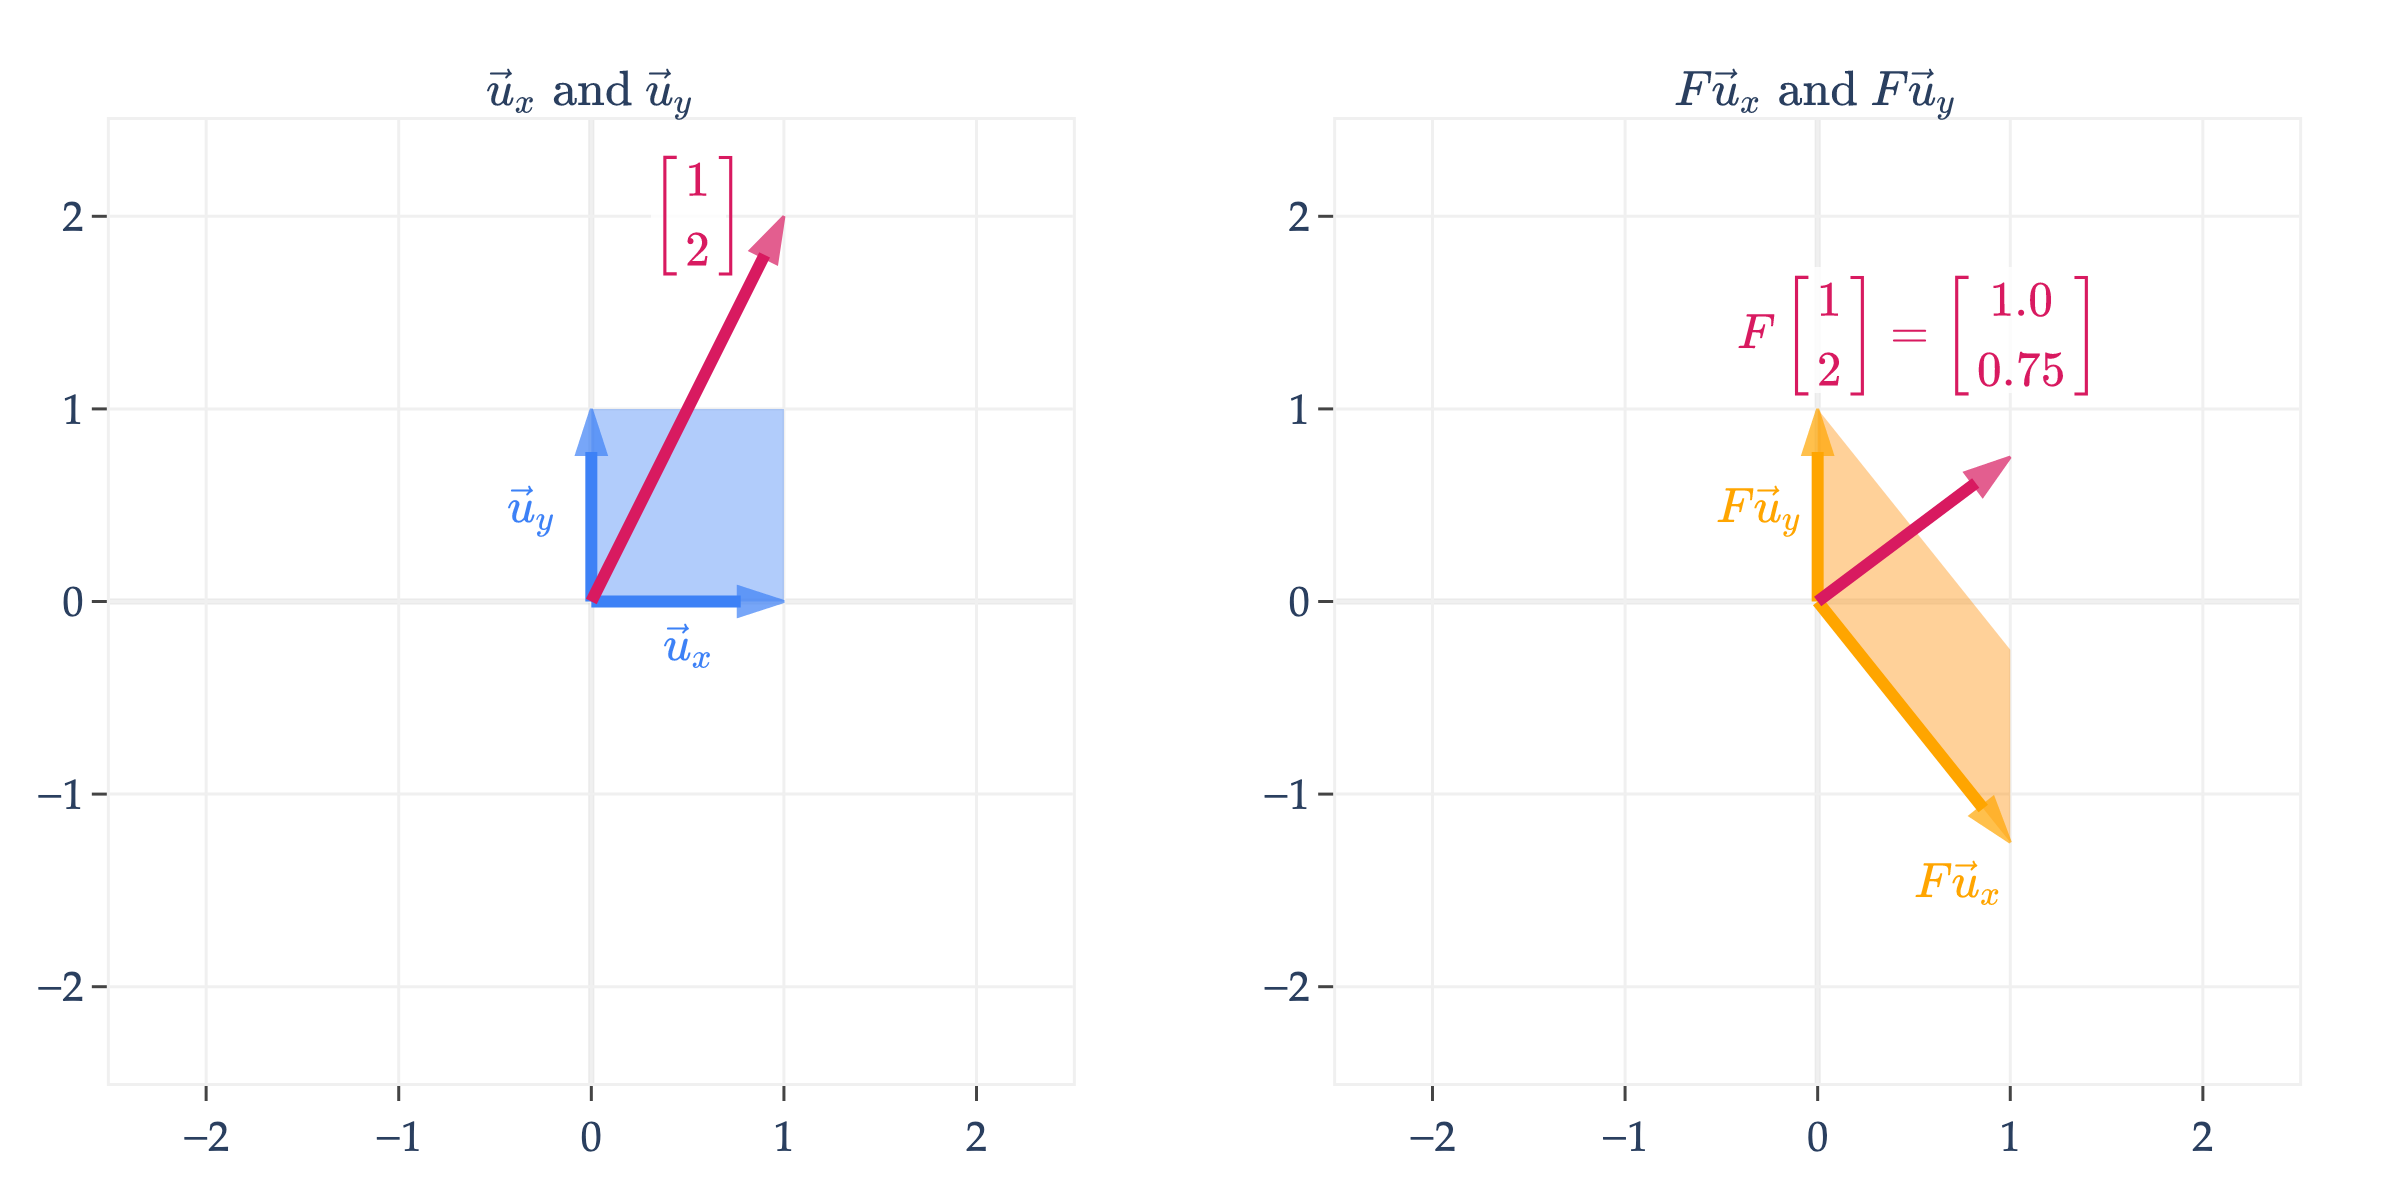

In [42]:
F = np.array([[1, 0], [-5 / 4, 1]])
# The vector to highlight
vec = np.array([1, 2])
# Its transformed position as a vector (i.e. F @ vec)
vec_trans = F @ vec

# Plot the transformation and get the figure object
fig = plot_unit_square_and_transform(
    F, 
    name="F", 
    vdeltay=-1.3, 
    vdeltax=0.3,
    return_fig=True
)

# Use add_vectors_to_subplot to overlay the original and transformed vectors
add_vectors_to_subplot(
    fig,
    list_of_vecs=[vec],
    start_points=[np.array([0, 0])],
    colors=["#d81a60"],
    labels=[fr"$\begin{{bmatrix}} {vec[0]} \\ {vec[1]} \end{{bmatrix}}$"],
    row=1, col=1,
    vdeltay=2.3
)

add_vectors_to_subplot(
    fig,
    list_of_vecs=[vec_trans],
    start_points=[np.array([0, 0])],
    colors=["#d81a60"],
    labels=[fr"$F\begin{{bmatrix}} {vec[0]} \\ {vec[1]} \end{{bmatrix}} = \begin{{bmatrix}} {vec_trans[0]} \\ {vec_trans[1]} \end{{bmatrix}}$"],
    row=1, col=2,
    vdeltay=1.3
)

fig.show(renderer='png', scale=3)

On the other hand, if we look at

$$H = \begin{bmatrix} 1 / 2 & -1 \\ 1 & -2 \end{bmatrix}$$

the same does not hold true. Given any vector $\vec b \in \text{colsp}(H)$ on the right, there are infinitely many vectors $\vec x$ such that $H \vec x = \vec b$. <span style="color:#d81a60; font-weight:bold">The vectors in pink on the left are all sent to the same vector on the right,</span> $\color{#d81a60}{\begin{bmatrix} -1 \\\\ -2 \end{bmatrix}}$.

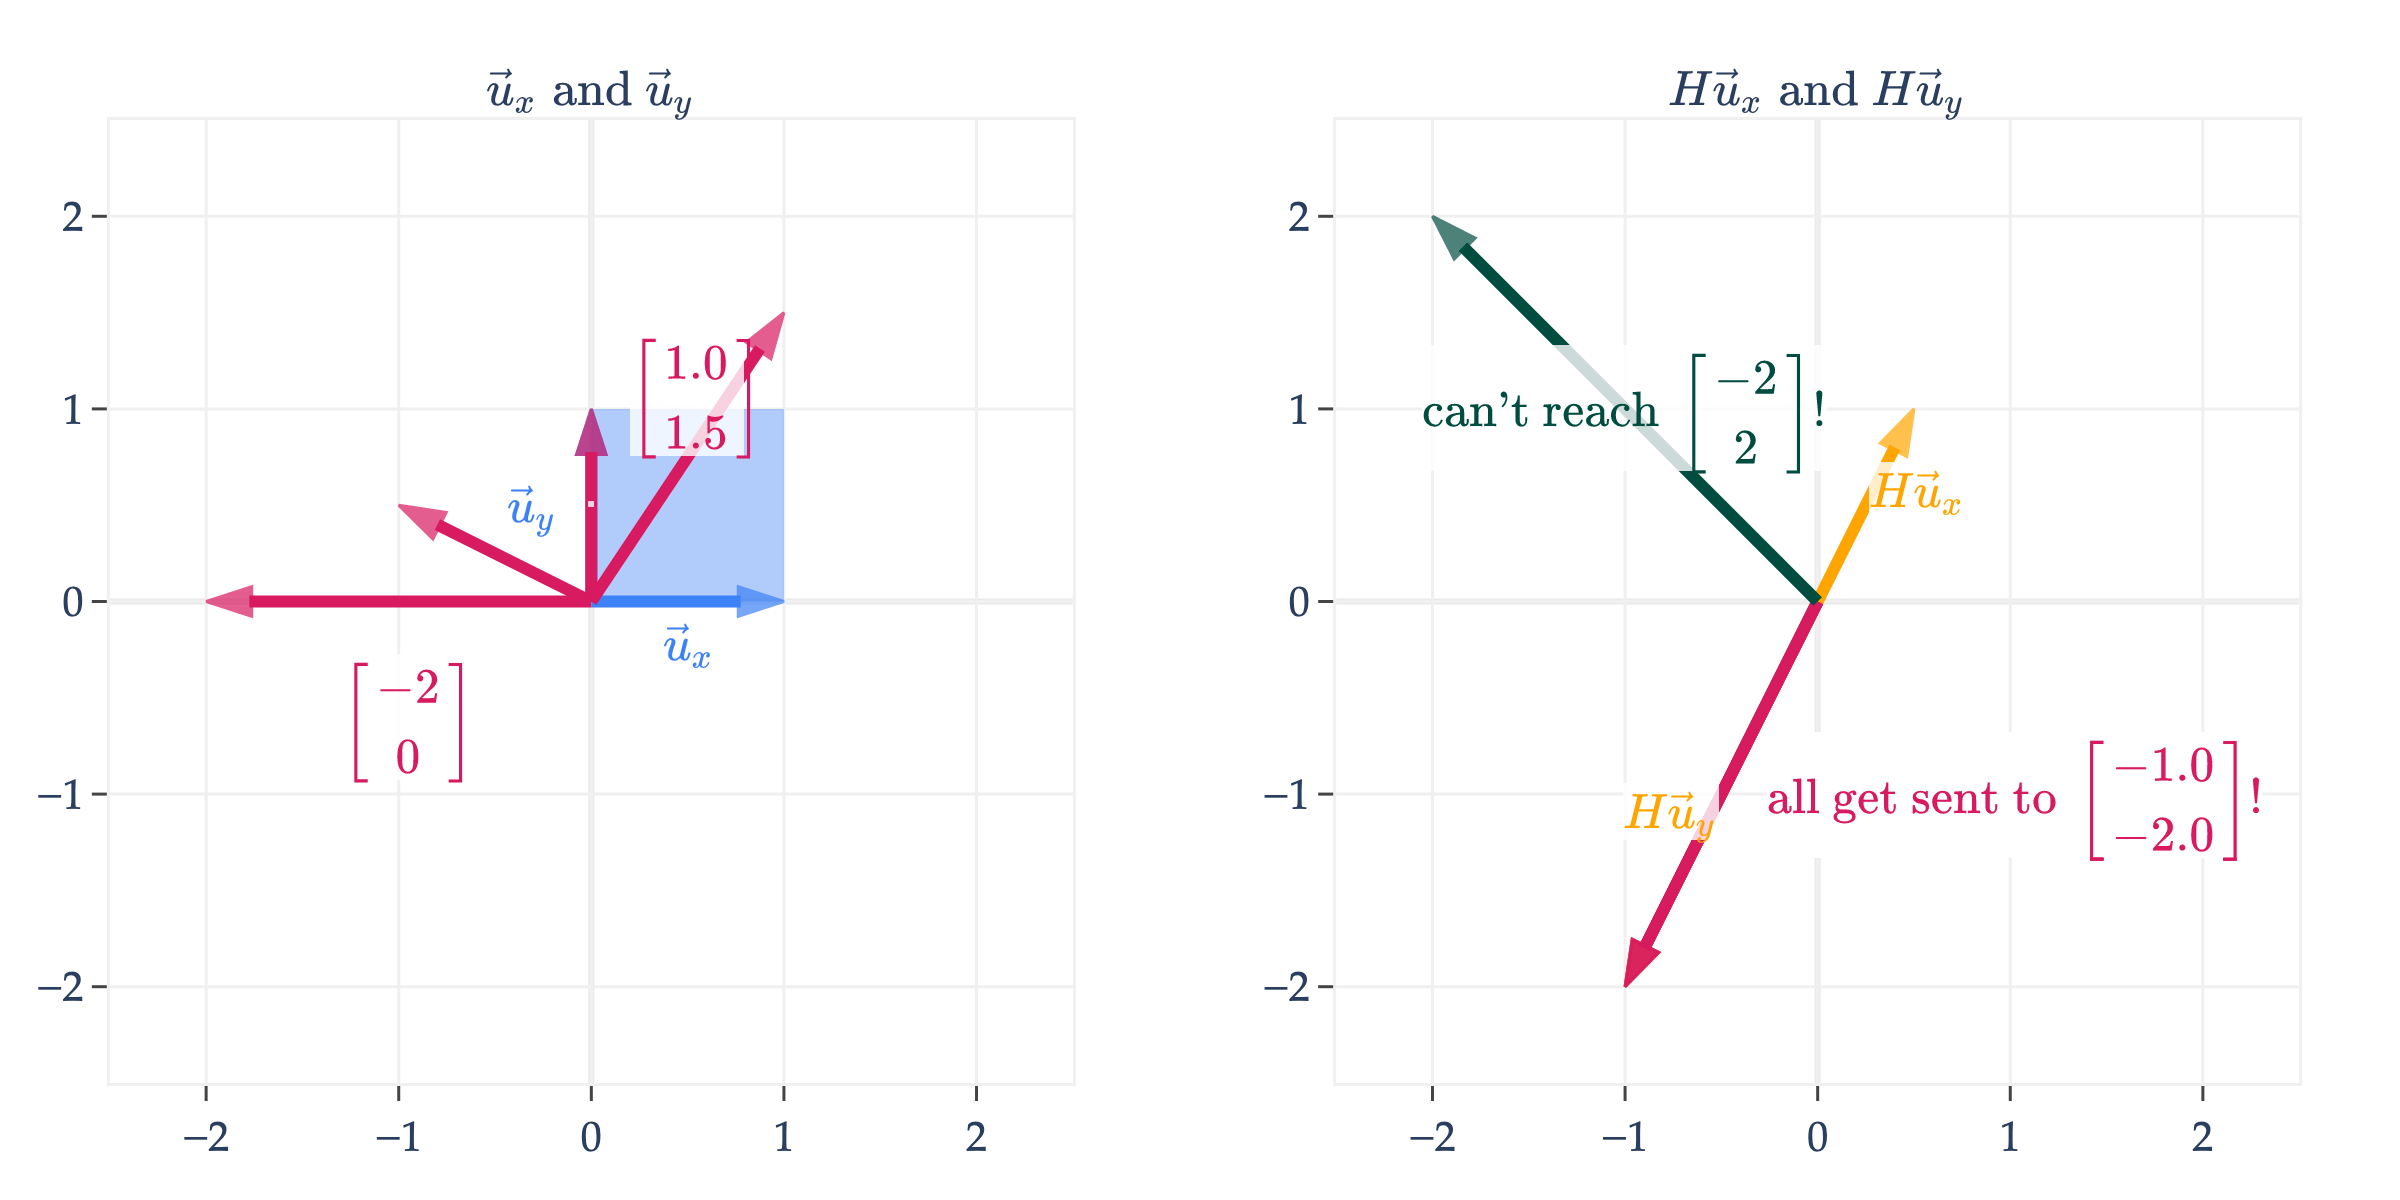

In [67]:
H = np.array([[1 / 2, -1], [1, -2]])

# Points to highlight
pts = [np.array([0, 1]), np.array([1, 1.5]), np.array([-1, 0.5]), np.array([-2, 0])]
# Their transformed positions
pts_trans = [H @ pt for pt in pts]

# Plot the transformation and get the figure object
fig = plot_unit_square_and_transform(
    H, 
    name="H", 
    return_fig=True
)

# Use add_vectors_to_subplot to overlay the original points on the left (input) subplot
add_vectors_to_subplot(
    fig,
    list_of_vecs=pts,
    start_points=[np.array([0, 0]) for _ in pts],
    colors=["#d81a60"] * len(pts),
    labels=[
        fr"$\begin{{bmatrix}} {pt[0]} \\ {pt[1]} \end{{bmatrix}}$" if i in [3, 1] else ""
        for i, pt in enumerate(pts)
    ],
    row=1, col=1,
    vdeltay=0.6
)

# Use add_vectors_to_subplot to overlay the transformed points on the right (output) subplot
# We want to show that all points get sent to the same output
labels_right = [
    fr"$\text{{all get sent to }} \begin{{bmatrix}} {pt_t[0]} \\ {pt_t[1]} \end{{bmatrix}}!$"
    for pt_t in pts_trans
]
add_vectors_to_subplot(
    fig,
    list_of_vecs=pts_trans,
    start_points=[np.array([0, 0]) for _ in pts_trans],
    colors=["rgba(216, 26, 96, 0.7)"] * len(pts_trans),
    labels=labels_right,
    row=1, col=2,
    vdeltay=0,
    vdeltax=1.7
)

# Show a point that can't be reached
add_vectors_to_subplot(
    fig,
    list_of_vecs=[np.array([-2, 2])],
    start_points=[np.array([0, 0])],
    colors=["#004d40"],
    labels=[r"$\text{can't reach } \begin{bmatrix} -2 \\ 2 \end{bmatrix}!$"],
    row=1, col=2,
    vdeltay=0
)

fig.show(renderer='png', scale=3)

And, there are <span style="color:#004d40; font-weight:bold">no vectors</span> on the left that get sent to $\begin{bmatrix} -2 \\\\ 2 \end{bmatrix}$ on the right. Any vector in $\mathbb{R}^2$ that isn't on the line spanned by $\begin{bmatrix} -1 \\ -2 \end{bmatrix}$ is <span style="color:#004d40; font-weight:bold">unreachable</span>.

You may recall the following key ideas from discrete math:
- A function is **invertible** if and only if it is both **one-to-one** (injective) and **onto** (surjective).
- A function is **one-to-one** if and only if no two inputs get sent to the same output, i.e. $f(x_1) = f(x_2)$ implies $x_1 = x_2$.
- A function is **onto** if every element of the codomain is an output of the function, i.e. for every $y \in Y$, there exists an $x \in X$ such that $f(x) = y$.

The transformation represented by $H$ is neither one-to-one (because $\begin{bmatrix} 0 \\ 1 \end{bmatrix}$ and $\begin{bmatrix} 1 \\ 1.5 \end{bmatrix}$ get sent to the same point) nor onto (because $\begin{bmatrix} -2 \\ 0 \end{bmatrix}$ isn't mapped to by any vector in $\mathbb{R}^2$).

In order for a linear transformation to be invertible, it must be **both one-to-one and onto**, i.e. it must be a **bijection**. Again, don't worry if these terms seem foreign: I've provided them here to help build connections to other courses _if_ you've taken them. If not, the rest of my coverage should still be sufficient.

---

## Inverting a Matrix

The big idea I'm trying to get across is that an $n \times n$ matrix $A$ is invertible if and only if the corresponding linear transformation can be "undone". In other words:

:::{attention} What makes $A$ invertible?
$A$ is invertible if and only if given any vector $\vec b \in \mathbb{R}^n$, **there is** <span style="color:#d81a60; font-weight: bold">exactly one</span> **vector $\vec x \in \mathbb{R}^n$ such that $A \vec x = \vec b$**. 
:::
If the visual intuition from earlier didn't make this clear, here's another concrete example. Consider

$$A = \begin{bmatrix} 1 & 2 & 0 \\ 1 & 2 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

$\text{rank}(A) = 2$, since $A$'s first two columns are scalar multiples of one another. Let's consider two possible $\vec b$'s, each depicting a different case.

1. $\vec b = \begin{bmatrix} 3 \\ 3 \\ 3 \end{bmatrix}$. This $\vec b$ is in $\text{colsp}(A)$. The issue with $A$ is that there are infinitely many linear combinations of the columns of $A$ that equal this $\vec b$.

$$\underbrace{\begin{bmatrix} 1 & 2 & 0 \\ 1 & 2 & 0 \\ 1 & 2 & 1 \end{bmatrix}}_{A} \underbrace{\begin{bmatrix} 1 \\ 1 \\ 0 \end{bmatrix}}_{\text{an } \vec x} = \underbrace{\begin{bmatrix} 1 & 2 & 0 \\ 1 & 2 & 0 \\ 1 & 2 & 1 \end{bmatrix}}_{A} \underbrace{\begin{bmatrix} -5 \\ 4 \\ 0 \end{bmatrix}}_{\text{another } \vec x} = ... = \underbrace{\begin{bmatrix} 3 \\ 3 \\ 3 \end{bmatrix}}_{\vec b}$$

2. $\vec b = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}$. This $\vec b$ is **not** in $\text{colsp}(A)$, meaning there is no $\vec x \in \mathbb{R}^3$ such that $A \vec x = \vec b$.

$$\underbrace{\begin{bmatrix} 1 & 2 & 0 \\ 1 & 2 & 0 \\ 1 & 2 & 1 \end{bmatrix}}_{A} \underbrace{\begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}}_{\text{no such } \vec x} = \underbrace{\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}}_{\vec b}$$

But, if $A$'s columns were linearly independent, they'd span all of $\mathbb{R}^3$, and so $A \vec x = \vec b$ would have a **unique** solution $\vec x$ for any $\vec b$ we think of.

### Definition

:::{note} Definition: Inverse of a Matrix
An $n \times n$ matrix $A$ is **invertible** if and only if $A$'s columns are linearly independent.

The sentence above is enough to define invertibility, but there are plenty of other equivalent conditions that guarantee invertibility:

- $\text{rank}(A) = n$ (i.e., $A$ is **full rank**)
- $A$'s columns are linearly independent (and hence $\text{colsp}(A) = \mathbb{R}^n$)
- $A$'s rows are linearly independent (and hence $\text{rowsp}(A) = \text{colsp}(A^T) = \mathbb{R}^n$)
- $A$'s null space contains only the zero vector
- $\text{det}(A) \neq 0$

If one of the above properties hold, they all hold. If one doesn't, they all don't.

If $A$ is invertible, its inverse $A^{-1}$ is the **unique** $n \times n$ matrix such that $$A A^{-1} = I = A^{-1} A$$

If $A$ is not invertible, we say that $A$ is **singular**.
:::

The properties in the box above are sometimes together called the **invertible matrix theorem**. This is not an exhaustive list, either, and we'll see other equivalent properties as time goes on.

### Inverse of a $2 \times 2$ Matrix

As was the case with the determinant, the general formula for the inverse of a matrix is only convenient for $2 \times 2$ matrices.

:::{note} Definition: Inverse of a $2 \times 2$ matrix
If $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$ and $A$ is invertible, then

$$A^{-1} = \frac{1}{ad - bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$
:::

You could solve for this formula by hand, by finding scalars $e$, $f$, $g$, and $h$ such that

$$\underbrace{\begin{bmatrix} a & b \\ c & d \end{bmatrix}}_A \begin{bmatrix} e & f \\ g & h \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

Note that the formula above involves division by $ad - bc$. If $ad - bc = 0$, then $A$ is not invertible, but $ad - bc$ is just the determinant of $A$! This should give you a bit more confidence in the equivalence of the statements "$A$ is invertible" and "$\text{det}(A) \neq 0$".

Let's test out the $2 \times 2$ formula on some examples. If

$$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$$

then

$$A^{-1} = \frac{1}{1 \cdot 4 - 2 \cdot 3} \begin{bmatrix} 4 & -2 \\ -3 & 1 \end{bmatrix} = \frac{1}{-2} \begin{bmatrix} 4 & -2 \\ -3 & 1 \end{bmatrix} = \begin{bmatrix} -2 & 1 \\ 3/2 & -1/2 \end{bmatrix}$$

and indeed both

$$\begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix} \begin{bmatrix} -2 & 1 \\ 3/2 & -1/2 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

and

$$\begin{bmatrix} -2 & 1 \\ 3/2 & -1/2 \end{bmatrix} \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

hold.

On the other hand,

$$B = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$$

is not invertible, since its columns are linearly dependent.

:::{tip} Activity 1
:class: dropdown

Suppose $A$ is an invertible $n \times n$ matrix.

1. Is $A^T$ invertible? If so, what is its inverse?
2. What is $\text{det}(A^{-1})$?
3. Is $A^2$ invertible? If so, what is its inverse?
:::

### Beyond $2 \times 2$ Matrices

For matrices larger than $2 \times 2$, the calculation of the inverse is not as straightforward; there's no simple formula. In the $3 \times 3$ case, we'd need to find 9 scalars $c_{ij}$ such that

$$\underbrace{\begin{bmatrix} 3 & 7 & 1 \\ -2 & 5 & 0 \\ 4 & 2 & 0 \end{bmatrix}}_A \underbrace{\begin{bmatrix} {\color{#3d81f6}c_{11}} & {\color{orange}c_{12}} & {\color{#d81a60}c_{13}} \\ {\color{#3d81f6}c_{21}} & {\color{orange}c_{22}} & {\color{#d81a60}c_{23}} \\ {\color{#3d81f6}c_{31}} & {\color{orange}c_{32}} & {\color{#d81a60}c_{33}} \end{bmatrix}}_{C = A^{-1}} = \underbrace{\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}}_{I}$$

This involves solving a system of 3 equations in 3 unknowns, 3 times – one per column of the identity matrix. One such system is

$$
\begin{align*}
3 {\color{#3d81f6}c_{11}} + 7 {\color{#3d81f6}c_{21}} + {\color{#3d81f6}c_{31}} &= 1 \\
-2 {\color{#3d81f6}c_{11}} + 5 {\color{#3d81f6}c_{21}} &= 0 \\
4 {\color{#3d81f6}c_{11}} + 2 {\color{#3d81f6}c_{21}} &= 0
\end{align*}
$$

You can quickly see how this becomes a pain to solve by hand. Instead, we can use one of two strategies:

1. Using **row reduction**, also known as **Gaussian elimination**, which is an efficient method for solving systems of linear equations without needing to write out each equation explicitly. Row reduction can be used to both find the rank and inverse of a matrix, among other things. More traditional linear algebra courses spend a considerable amount of time on this concept, though I've intentionally avoided it in this course to instead spend time on conceptual ideas most relevant to machine learning. That said, you'll get some practice with it in a future homework.
2. Using a **pre-built function** in `numpy` that does the row reduction for us.

At the end of this section, I give you some advice on how to (and not to) compute the inverse of a matrix in code.

---

## More Examples

As we've come to expect, let's work through some examples that illustrate important ideas.

### Example: Inverting a Product

1. Suppose $A$ and $B$ are both invertible $n \times n$ matrices. Is $AB$ invertible? If so, what is its inverse?
1. Suppose $A = BC$, and $A$, $B$, and $C$ are all invertible $n \times n$ matrices. What is the inverse of $B$?
1. If $A$, $B$, and $AB$ are all $n \times n$ matrices, and $AB$ is invertible, must $A$ and $B$ both be invertible?
1. In general, if $AB$ is invertible, must $A$ and $B$ both be invertible?

:::{seealso} Solutions
:class: dropdown

1. If $A$ and $B$ are both invertible $n \times n$ matrices, then $AB$ is indeed invertible, with inverse

    $$(AB)^{-1} = B^{-1}A^{-1}$$

    To confirm, we should check that $B^{-1}A^{-1}$ is both the left inverse of $AB$, meaning $B^{-1}A^{-1}AB = I$, and that it is the right inverse of $AB$, meaning $ABB^{-1}A^{-1} = I$.

    $$B^{-1}\underbrace{A^{-1}A}_{I}B = B^{-1}B = I$$
    $$ABB^{-1}A^{-1} = AA^{-1} = I$$

1. Since we know that $A$, $B$, and $C$ are all invertible,

    $$A = BC \implies AA^{-1} = BCA^{-1} \implies I = BCA^{-1}$$

    This tells us that $CA^{-1}$ is the inverse of $B$, since multiplying $B$ by it gets us back to $I$. (For square matrices, it doesn't matter whether we multiply on the left or right; the inverse is the same and is unique.)

1. If $A$, $B$, and $AB$ are all $n \times n$ matrices, and $AB$ is invertible, then $A$ and $B$ must individually be invertible, too. One way to argue about this is using facts about determinants. Earlier, we learned

    $$\text{det}(AB) = \text{det}(A) \text{det}(B)$$

    If $AB$ is invertible, $\text{det}(AB) \neq 0$, but that must mean $\text{det}(A) \text{det}(B) \neq 0$ too, and so neither $\text{det}(A)$ nor $\text{det}(B)$ can be 0 either, meaning $A$ and $B$ are both invertible.

1. In general, if $AB$ is invertible, but we don't know anything about the shapes of $A$ and $B$, it's not necessarily true that $A$ and $B$ are individually invertible, because they may not be square! Consider

    $$AB = \underbrace{\begin{bmatrix} 3 & 0 & 0 \\ 0 & 2 & 0 \end{bmatrix}}_A \underbrace{\begin{bmatrix} 3 & 0 \\ 0 & 2 \\ 0 & 0 \end{bmatrix}}_B = \begin{bmatrix} 9 & 0 \\ 0 & 4 \end{bmatrix}$$

    $AB$ is an invertible $2 \times 2$ matrix, but neither $A$ nor $B$ are individually invertible, since neither is square.

:::

### Example: Inverting a Sum

Suppose $A$ and $B$ are both invertible $n \times n$ matrices. Is $A + B$ invertible? If so, what is its inverse?

:::{seealso} Solution
:class: dropdown

In general, **no**, $A + B$ is not guaranteed to be invertible.

As a counterexample, suppose $A$ is invertible, and that $B = -A$. Then, $B^{-1} = -A^{-1}$, but

$$A + B = 0$$

and a matrix of all 0's is not invertible (since it's columns don't span all of $\mathbb{R}^n$).

:::

### Example: Inverting $X^TX$

Suppose $X$ is an $n \times d$ matrix. Note that $X$ is not square, and so it is not invertible. However, $X^TX$ is a square matrix, and so it is possible that it is invertible.

Explain why $X^TX$ is invertible if and only if $X$'s columns are linearly independent.

:::{seealso} Solution
:class: dropdown

Recall that if $X$ is $n \times d$, then $X^TX$ is $d \times d$.

In [Chapter 5.4](../05_matrices/04-null-space-rank-nullity.ipynb#example-rank-of-x-tx), we proved that $$\text{rank}(X^TX) = \text{rank}(X)$$

The only way for $X^TX$ to be invertible is if $\text{rank}(X^TX) = d$. But, $\text{rank}(X^TX) = d$ if and only if $\text{rank}(X) = d$, which happens when all $d$ of $X$'s columns are linearly independent.

:::

### Example: Orthogonal Matrices

Recall, an $n \times n$ matrix $Q$ is **orthogonal** if $Q^T Q = QQ^T = I$.

What is the inverse of $Q$? Explain how this relates to the formula for rotation matrices in $\mathbb{R}^2$ from earlier,

$$R(\theta) = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix}$$

:::{seealso} Solution
:class: dropdown

Looking at $Q^TQ = QQ^T = I$, we see that

$$Q^{-1} = Q^T$$

since multiplying $Q$ by $Q^T$ on either side gets us back to $I$.

In $\mathbb{R}^2$, if

$$Q = R(\theta) = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix}$$

then

$$Q^T = \begin{bmatrix} \cos(\theta) & \sin(\theta) \\ -\sin( \theta) & \cos(\theta) \end{bmatrix} = \begin{bmatrix} \cos(-\theta) & -\sin(-\theta) \\ \sin(- \theta) & \cos(-\theta) \end{bmatrix} = R(-\theta)$$

since $\cos(-\theta) = \cos(\theta)$ and $\sin(-\theta) = -\sin(\theta)$. In English, if $Q$ corresponds to rotating by $\theta$ in the counterclockwise direction, $Q^T$ corresponds to rotating by $-\theta$ in the counterclockwise direction, i.e. by $\theta$ in the opposite direction.

:::

### Example: Householder Reflection

Suppose $\vec u \in \mathbb{R}^n$ is a **unit vector**. Let

$$P = I - 2 \vec u \vec u^T$$

$P$ is called the **Householder** matrix. $f(\vec x) = P \vec x$ reflects $\vec x$ across the line in $\mathbb{R}^2$ (or plane in $\mathbb{R}^3$, or in general, hyperplane in $\mathbb{R}^n$)  $\vec u^T \vec x = 0$.

For example, suppose $\vec u = \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix}$. Then,

$$P = I - 2 \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix} \begin{bmatrix} 3/5 & 4/5 \end{bmatrix} = \begin{bmatrix} 7/25 & -24/25 \\ -24/25 & 7/25 \end{bmatrix}$$

reflects $\vec x$ across the line $\begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix} \cdot \vec x = 0$, i.e. $\frac{3}{5}x_1 + \frac{4}{5}x_2 = 0$, or $x_2 = -\frac{3}{4}x_1$, or in more interpretable syntax, $y = -\frac{3}{4}x$.

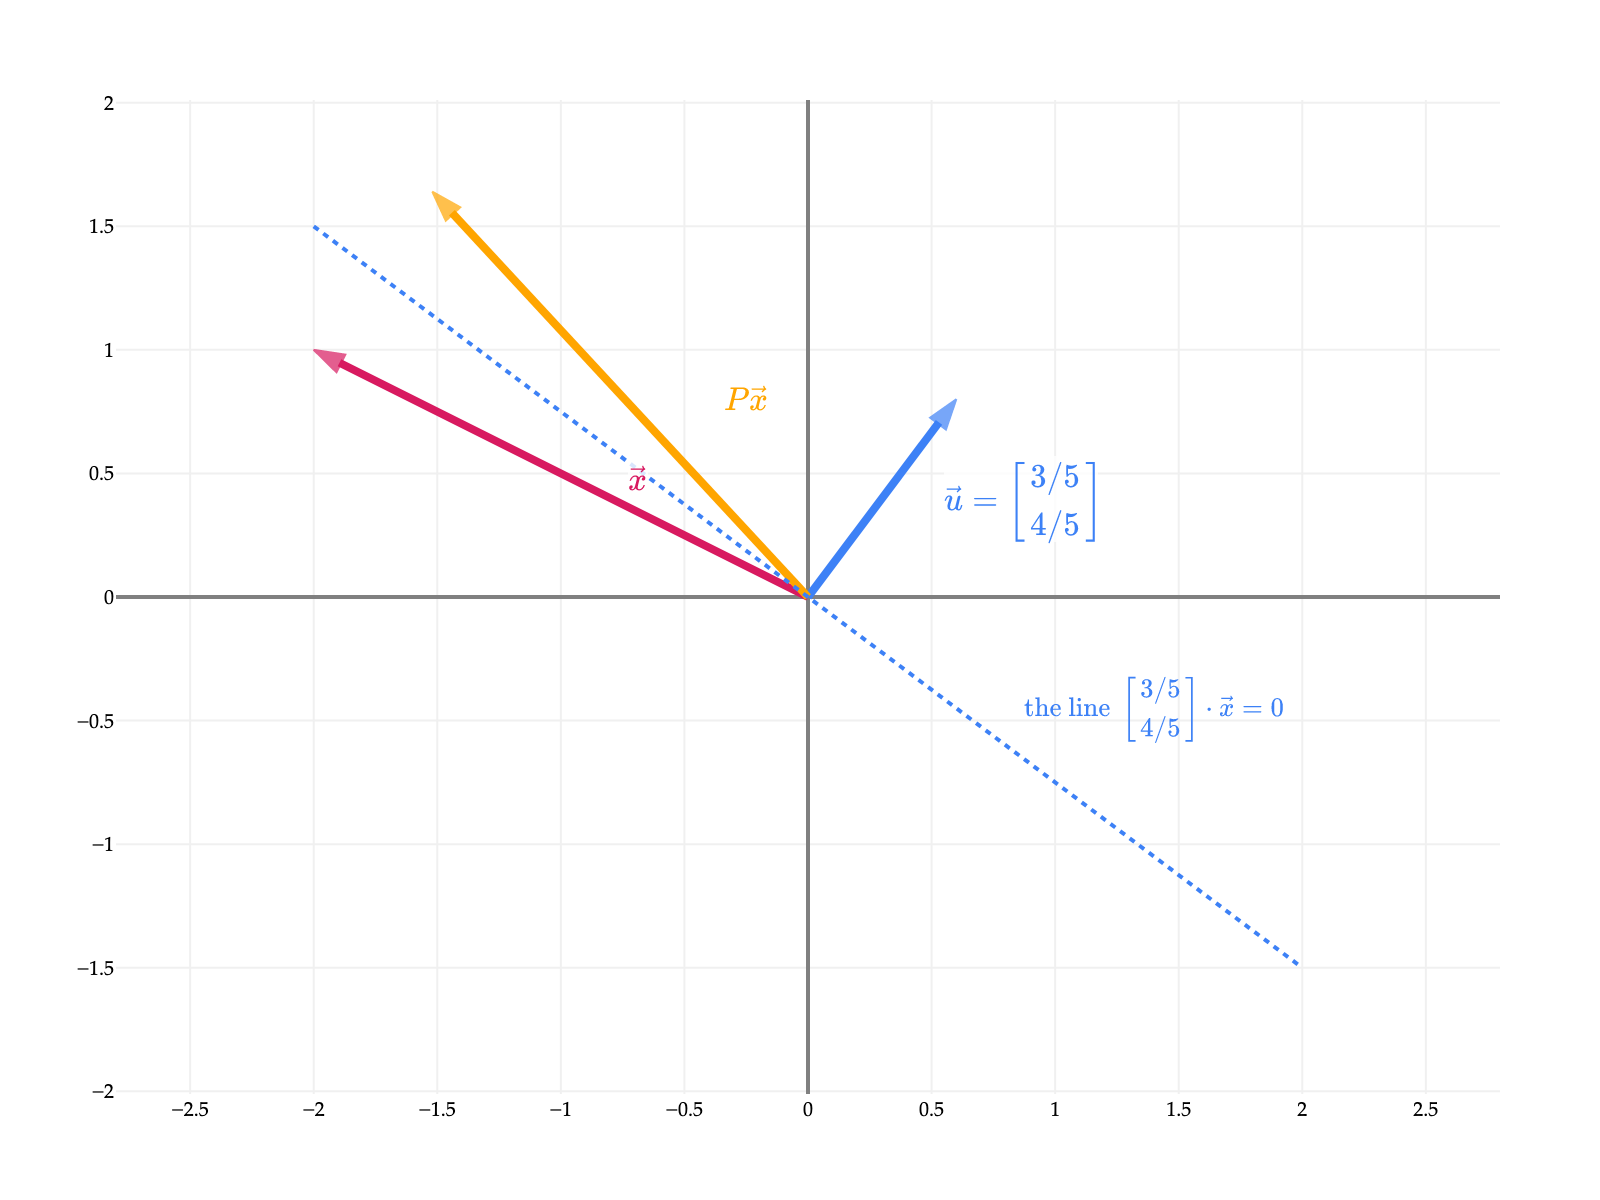

In [25]:
from utils import plot_vectors
import numpy as np

# Define normal vector (unit)
n = np.array([3 / 5, 4 / 5])

# Line normal to n: 3x + 4y = 0 (i.e., n • x = 0)
# Let's find two points on the line: choose x=-2 and x=2
# Then, 3x + 4y = 0 --> y = -(3/4)x
xs = np.array([-2, 2])
ys = -(3 / 4) * xs
line_points = np.column_stack([xs, ys])

# x and its reflection P(x)
x = np.array([-2, 1])

# Householder reflection matrix P = I - 2 n n^T
P = np.eye(2) - 2 * np.outer(n, n)
Px = P @ x

elements = [
    (tuple(n), '#3d81f6', r"$\vec u = \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix}$"),  # Plot n (unit vector) in blue
    (tuple(x), '#d81a60', r"$\vec x$"),
    (tuple(Px), 'orange', r"$P\vec x$"),
]

fig = plot_vectors(elements, vdeltay=0, vdeltax=-0.7)

# Draw the dotted line x=y (normal to n) and label it
fig.add_trace({
    'type': 'scatter',
    'x': line_points[:, 0],
    'y': line_points[:, 1],
    'mode': 'lines',
    'line': {'color': '#3d81f6', 'dash': 'dot'},
})

# Annotate the line as "line" (at x=1.3, y=1.3)
fig.add_annotation(
    x=1.4, y=-0.5, 
    text=r"$\text{the line } \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix} \cdot \vec x = 0$",
    showarrow=False,
    yshift=8,
    font=dict(size=13, color='#3d81f6')
)

# Adjust plot range and aspect ratio
fig.update_layout(
    xaxis=dict(range=[-2, 2], dtick=0.5),
    yaxis=dict(scaleanchor="x", range=[-2, 2], dtick=0.5),
    showlegend=False
)

fig.show(scale=2, renderer='png')

1. Show, just using the definition $P = I - 2 \vec u \vec u^T$, that $P$ is an orthogonal matrix.
1. Find $P^{-1}$. (Why does the fact that $P$ is orthogonal imply that $P$ is invertible?)

:::{seealso} Solution
:class:dropdown

If we want to show that $P$ is orthogonal, then we need to show that $P^TP = PP^T = I$. Let's start by showing that $P^TP = I$. Note that $(\vec u \vec u^T)^T = \vec u \vec u^T$.

\begin{align*}
P^T P &= (I - 2 \vec u \vec u^T)^T (I - 2 \vec u \vec u^T) \\
&= (I^T - 2 (\vec u \vec u^T)^T) (I - 2 \vec u \vec u^T) \\
&= (I - 2 (\vec u^T)^T \vec u^T) (I - 2 \vec u \vec u^T) \\
&= (I - 2 \vec u \vec u^T) (I - 2 \vec u \vec u^T) \\
&= I - 2 \vec u \vec u^T - 2 \vec u \vec u^T + 4 (\vec u \vec u^T) (\vec u \vec u^T) \\
&= I - 4 \vec u \vec u^T + 4 (\vec u \vec u^T) (\vec u \vec u^T) \\
&= I - 4 \vec u \vec u^T + 4 \vec u \underbrace{\vec u^T \vec u}_\text{unit vector!} \vec u^T \\
& = I - 4 \vec u \vec u^T + 4 \vec u (1) \vec u^T \\
&= I
\end{align*}

This means that $P$'s inverse is just $P^T$, since we multipled $P$ by $P^T$ to get $I$. This also means that $PP^T = I$ too, since a square matrix's inverse is unique and can be multiplied on either side to get $I$. So, $P$ is indeed orthogonal.

Note that in the final step above, the $-4 \vec u \vec u^T$ and $4 \vec u \vec u^T$ cancelled out. But, the $-4$ came from $-2 - 2$, while the $4$ came from $(-2) \cdot (-2)$. All of this is to say that if we changed the $-2$ to some other number in the definition of the Householder matrix, we'd no longer have $P^TP = I$, because $-2$ is the only non-zero solution to $-(c + c) = c \cdot c$.

As mentioned above, $P$ is invertible: $P^{-1} = P^T$. But, implicitly we also showed that $P^T = P$, meaning $P$ is symmetric:

$$P^T = (I - 2\vec u \vec u^T)^T = I - 2\vec u \vec u^T = P$$

So, $P$ is both **orthogonal and symmetric**! This means that $P^2 = I$, or i.e. $P = P^{-1}$.

Intuitively, $P$ involves reflecting across a line, so $P^TP = P^2$ involves reflecting twice, which is the same as doing nothing, and the inverse of $P$ is the same as $P$ itself.
:::

### Example: $A^2$ and $A$

Prove that if $A^2$ is invertible, then $A$ is invertible. Do so in three different ways:

1. By constructing $A$'s inverse directly.
2. By arguing about the null spaces of $A^2$ and $A$.
3. By using the determinant.

<iframe width="560" height="315" src="https://www.youtube.com/embed/dv-ADtlgK8k?si=3Q0IVmRobFqQyWpq" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

:::{seealso} Solution
:class: dropdown

**Solution 1: By direct construction**

One way to prove that $A$ is invertible is to find its inverse. Since $A^2$ is invertible, there must exist some matrix $B$ such that

$$A^2 B = I, \quad BA^2 = I$$

Note that the inclusion of both orders is important, since in general, order matters for matrix multiplication. Writing $A^2 = AA$ in the first equation gives us

$$A(AB) = I$$

This tells us that $AB$ is the inverse of $A$, so $A$ is invertible.

If we used the second equation instead, we'd have

$$(BA)A = I$$

So, we'd call $AB$ the right inverse of $A$ (since it's the inverse that multiplies on the right) and $BA$ the left inverse. A general fact is that if $A$ has both a left and right inverse, they must be the same, meaning that $AB$ must be equal to $BA$ here (remember this is not true in general for arbitrary matrices $A$ and $B$). A quick proof of this is

$$BA = BAI = BA(AAB) = BAAAB = (BAA)AB = IAB = AB$$

So, in short, $A^{-1} = AB = BA$, and since we've found $A$'s inverse, $A$ must be invertible.

**Solution 2: The null space perspective**

Let's argue by contradiction. Suppose $A^2$ is invertible, but $A$ is not. This would imply that $A^2$ null space is just the zero vector, $\vec 0$, while $A$'s null space is not just $\vec 0$. Suppose $\vec x$ is some vector \textbf{other than $\vec 0$} in $\text{nullsp}(A)$, meaning that

$$A \vec x = \vec 0$$

But, left-multiplying both sides by $A$ gives us

$$A(A \vec x) = A \vec 0 \implies A^2 \vec x = \vec 0$$

This tells us that $\vec x$ is in the null space of $A^2$, since $A^2 \vec x = \vec 0$. But, this contradicts our assumption that $A^2$ is invertible, because the only vector in the null space of an invertible matrix is the zero vector. So, our original assumption that $A$ is not invertible must be false, and $A$ must be invertible.

**Solution 3: The determinant perspective**

A fact from [Chapter 6.1](./linear-transformations-and-projections/linear-transformations#the-determinant) is that if $A$ and $B$ are two $n \times n$ matrices, then

$$\text{det}(A) \text{det}(B) = \text{det}(AB)$$

So, $$\text{det}(A^2) = \text{det}(A \cdot A) = \text{det}(A) \cdot \text{det}(A) = \text{det}(A)^2$$

But, we also know that invertible matrices have non-zero determinants, so we're given that $\text{det}(A^2) \neq 0$. But, since $\text{det}(A^2) = \text{det}(A)^2$, this implies that $\text{det}(A)^2 \neq 0$, and so $\text{det}(A) \neq 0$ too, and so $A$ is invertible.
:::

### Example: Matrix-Vector Products

If $A \begin{bmatrix} 3 \\ 1 \\ -1 \end{bmatrix} = \begin{bmatrix} 9 \\ 4 \\ 3 \end{bmatrix}$ and $A \begin{bmatrix} 4 \\ 0 \\ 2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$, is $A$ invertible?

:::{seealso} Solution
:class: dropdown

No, $A$ is not invertible. This is because its columns are linearly dependent, or equivalently, it has a non-trivial null space. This comes from the fact that $$A \begin{bmatrix} 4 \\ 0 \\ 2 \end{bmatrix} = \vec 0$$ which means that $\begin{bmatrix} 4 \\ 0 \\ 2 \end{bmatrix}$ is in the null space of $A$.
:::

---

## Computing the Inverse in Code

Recall that if $A$ is an $n \times n$ matrix and $\vec b \in \mathbb{R}^n$, then 
$$A \vec x = \vec b$$

is a system of $n$ equations in $n$ unknowns. One of the big (conceptual) usages of the inverse is to solve such a system, as I mentioned at the start of this section. If $A$ is invertible, then we can solve for $\vec x$ by multiplying both sides on the left by $A^{-1}$:

$$A \vec x = \vec b \implies A^{-1} A \vec x = A^{-1} \vec b \implies \vec x = A^{-1} \vec b$$

$A^{-1}$ has encoded within it the solution to $A \vec x = \vec b$, no matter what $\vec b$ is. This makes $A^{-1}$ very powerful. But, that power doesn't come for free: in practice, finding $A^{-1}$ is **less efficient and more prone to floating point errors** than solving the **one** system of $n$ equations in $n$ unknowns directly for the specific $\vec b$ we care about. 

- Solving $A \vec x = \vec b$ involves solving just one system of $n$ equations in $n$ unknowns.
- Finding $A^{-1}$ involves solving a system of $n$ equations in $n$ unknowns, $n$ times! Each system has the same coefficient matrix $A$ but a different right-hand side $\vec b$, corresponding to the columns of the identity matrix (which are the standard basis vectors in $\mathbb{R}^n$).

The more floating point operations we need to do, the more error is introduced into the final results.

Let's run an experiment. Suppose we'd like to find the solution to the system

\begin{align*}
x_1 + x_2 &= 7 \\
x_1 + 1.000000001 x_2 &= 7.000000004
\end{align*}

This corresponds to $A \vec x = \vec b$, with

$$A = \begin{bmatrix} 1 & 1 \\ 1 & 1.000000001 \end{bmatrix}, \quad \vec b = \begin{bmatrix} 7 \\ 7.000000004 \end{bmatrix}$$

Here, we can eyeball the solution as being $\vec x = \begin{bmatrix} 3 \\ 4 \end{bmatrix}$. How close to this "true" $\vec x$ do each of the following techniques get?

**Option 1**: Using `np.linalg.inv`

As we saw at the start of the section, `np.linalg.inv(A)` finds the inverse of `A`, assuming it exists. The following cell finds the solution to $A \vec x = \vec b$ by first computing $A^{-1}$, and then $A^{-1} \vec b = \vec x$.

In [83]:
# Prevents unnecessary rounding.
np.set_printoptions(precision=16, suppress=True)

A = np.array([[1, 1],
              [1, 1.000000001]])

b = np.array([[7],
              [7.000000004]])

x_inv = np.linalg.inv(A) @ b
x_inv

array([[2.9999998807907104],
       [4.0000001192092896]])

**Option 2**: Using `np.linalg.solve`

The following cell solves the same problem as the previous cell, but rather than asking for the inverse of $A$, it asks for the solution to $A \vec x = \vec b$, which doesn't inherently require inverting $A$.

In [91]:
x_solve = np.linalg.solve(A, b)
x_solve

array([[3.],
       [4.]])

This small example already illustrates the big idea: inverting can introduce more numerical error than is necessary. If we cast the problem more abstractly, consider the matrix

$$A = \begin{bmatrix} 1 & 1 \\ 1 & 1 + \epsilon \end{bmatrix}$$

where $\epsilon$ is a small constant, e.g. $\epsilon = 0.000000001$ in the example above. The inverse of $A$ is

$$A^{-1} = \frac{1}{1(1 + \epsilon) - 1 \cdot 1} \begin{bmatrix} 1 + \epsilon & -1 \\ -1 & 1 \end{bmatrix} = \frac{1}{\epsilon} \begin{bmatrix} 1 + \epsilon & -1 \\ -1 & 1 \end{bmatrix} $$

The closer $\epsilon$ is to 0, the larger $\frac{1}{\epsilon}$ becomes, making any floating point errors all the more costly.

:::{warning} Use `np.linalg.solve` instead of `np.linalg.inv`!
Conceptually, both
`x = np.linalg.inv(A) @ b`
and
`x = np.linalg.solve(A, b)`
do the same thing, but we **much prefer** the latter.
:::

<iframe width="560" height="315" src="https://www.youtube.com/embed/HZtoekU9NcE" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe>